<a href="https://colab.research.google.com/github/aburafiar/Data-Science/blob/Project/Bivariateand_Multivariet_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np
flights=sns.load_dataset('flights')
iris= sns.load_dataset('iris')
tips=sns.load_dataset('tips')
df = sns.load_dataset('titanic')

Bivariate Analysis : Analysing two columns like numerical numerical , numerical categorical, categorical , categorical

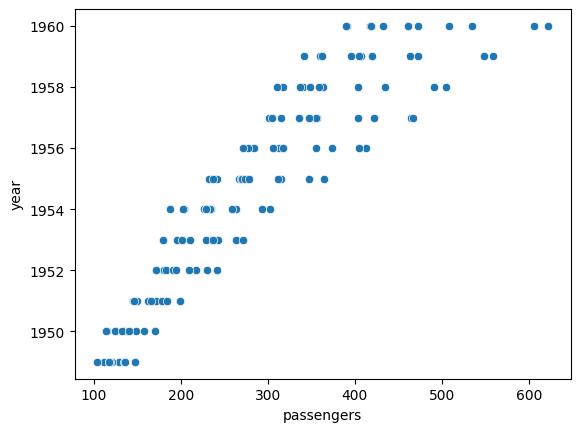

In [ ]:
sns.scatterplot(x=flights['passengers'],y=flights['year'])
plt.show()

Multivariat Analysis

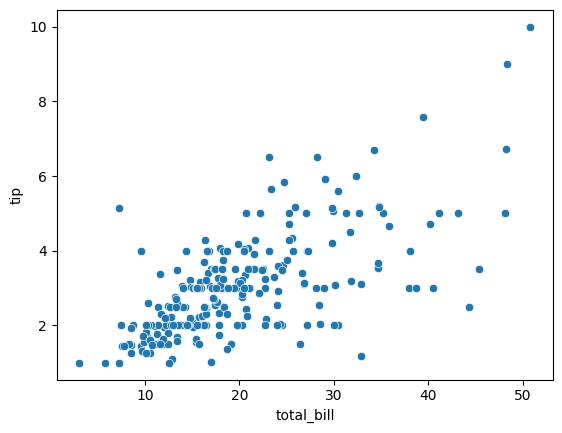

In [ ]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'])
plt.show()

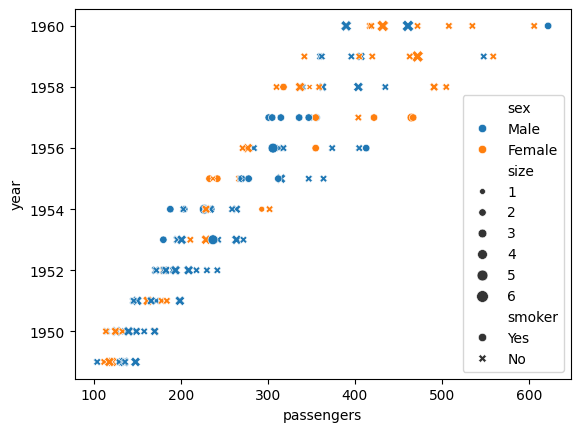

In [ ]:
sns.scatterplot(x=flights['passengers'],y=flights['year'],hue=tips['sex'],style=tips['smoker'],size=tips['size'])
plt.show()

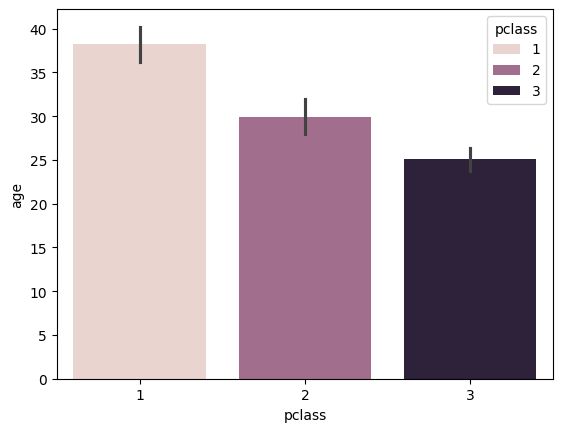

In [ ]:
# x is suggested for the numric and y for categorical data type
# black rod is called confidence interval you learn in statics
#hud is for different class
sns.barplot(x=df['pclass'],y=df['age'],hue=df['pclass'])
plt.show()

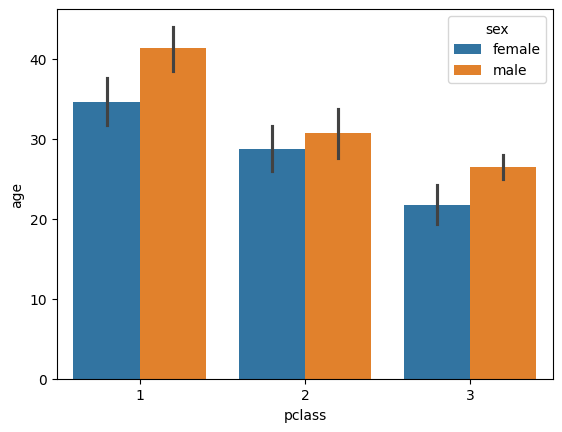

In [ ]:
# x is suggested for the numric and y for categorical data type
# black rod is called confidence interval you learn in statics
#hud is for different class
#hue = "group the data by this column and give each group a different color."
sns.barplot(x=df['pclass'],y=df['age'],hue=df['sex'])
plt.show()

/tmp/ipykernel_3347/1085620333.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['survived']==0]['age'],hist=False)
/tmp/ipykernel_3347/1085620333.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['survived']==1]['age'],hist=False)


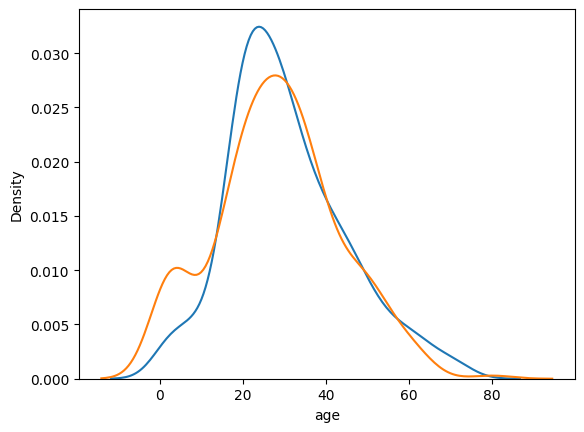

In [ ]:
sns.distplot(df[df['survived']==0]['age'],hist=False)
sns.distplot(df[df['survived']==1]['age'],hist=False)
plt.show()
#

# categorical and categorical column

In [ ]:
pd.crosstab(df['pclass'],df['survived'])

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


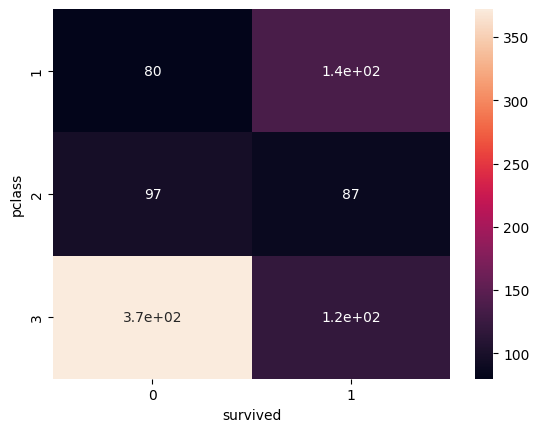

In [ ]:
sns.heatmap(pd.crosstab(df['pclass'],df['survived']),annot=True)
plt.show()


In [ ]:
df['survived'] = pd.to_numeric(df['survived'], errors='coerce')
df.groupby('pclass')['survived'].mean()*100

,survived
pclass,
1,62.962963
2,47.282609
3,24.236253


In [ ]:
pd.crosstab(df['sibsp'],df['survived'])

survived,0,1
sibsp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


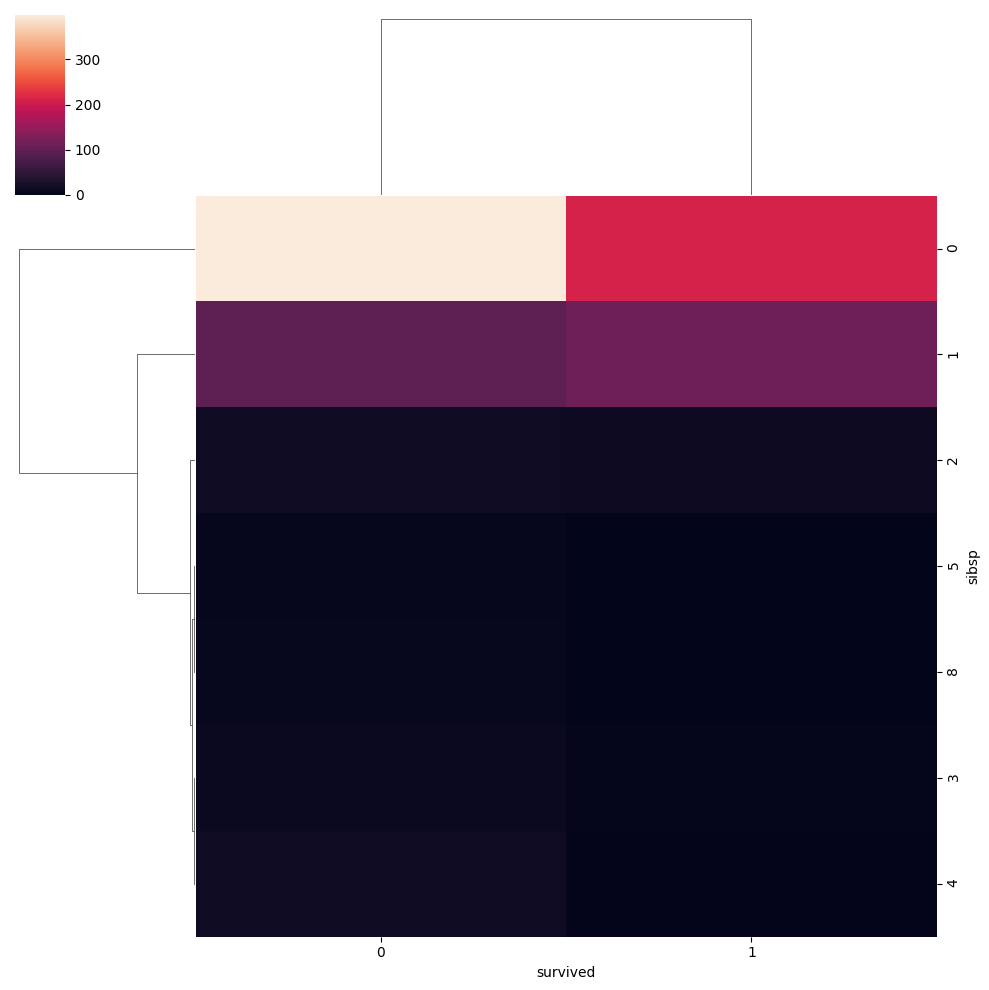

In [ ]:
sns.clustermap(pd.crosstab(df['sibsp'],df['survived']))

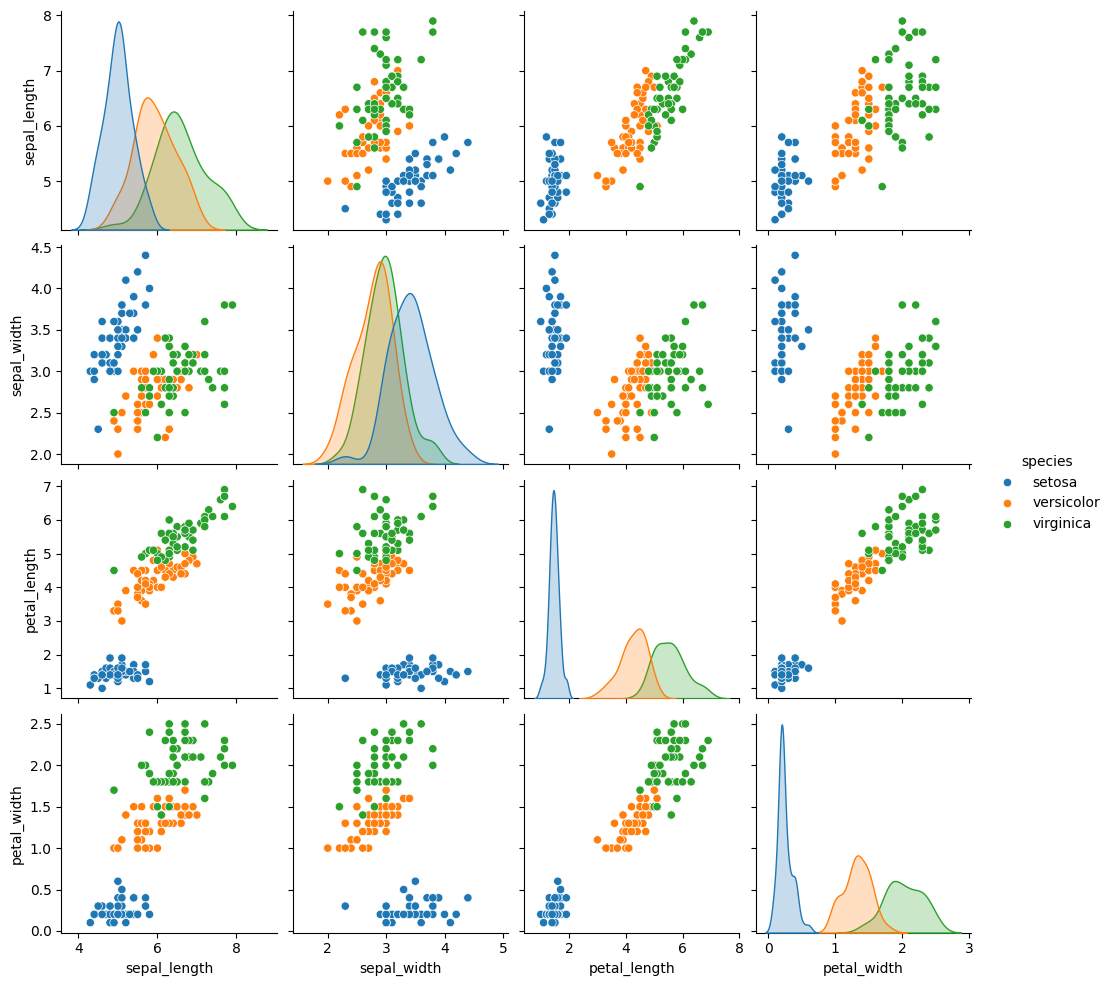

In [ ]:
sns.pairplot(iris,hue='species')
plt.show()

Lineplot(numerical-Numerical) when x axis is time based

In [ ]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


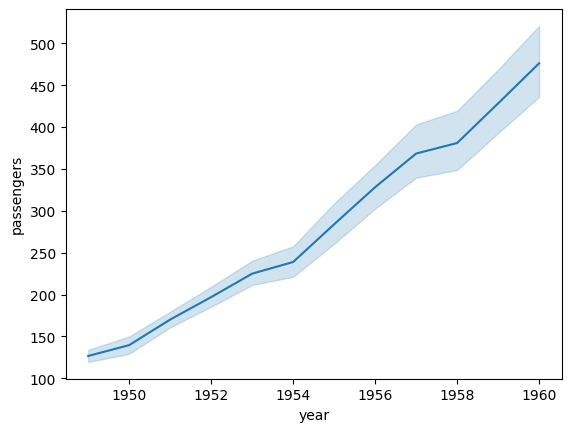

In [ ]:
sns.lineplot(x=flights['year'],y=flights['passengers'])
plt.show()

In [ ]:
flights.groupby(['year','month'])['passengers'].sum()

/tmp/ipykernel_3347/3704443786.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  flights.groupby(['year','month'])['passengers'].sum()


year  month
1949  Jan      112
      Feb      118
      Mar      132
      Apr      129
      May      121
              ... 
1960  Aug      606
      Sep      508
      Oct      461
      Nov      390
      Dec      432
Name: passengers, Length: 144, dtype: int64

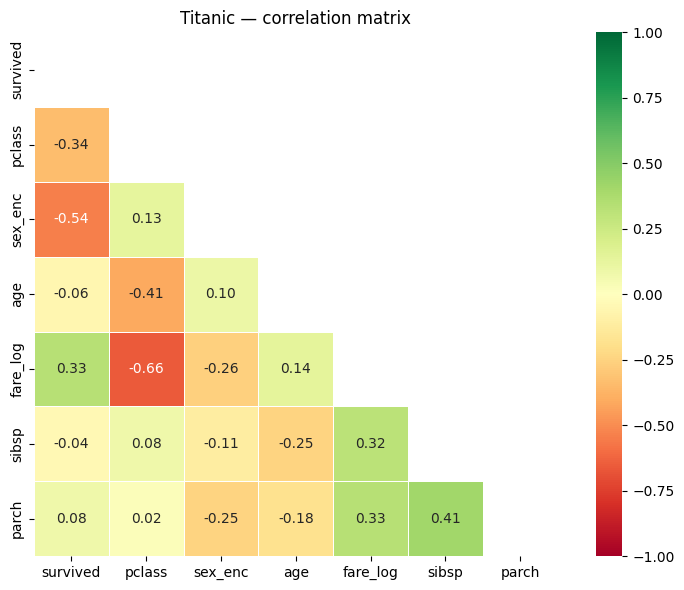

sex_enc    -0.54
pclass     -0.34
age        -0.06
sibsp      -0.04
parch       0.08
fare_log    0.33
survived    1.00
Name: survived, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df['age']      = df.groupby(['pclass','sex'])['age'].transform(lambda x: x.fillna(x.median()))
df['fare_log'] = np.log1p(df['fare'])
df['sex_enc']  = (df['sex'] == 'male').astype(int)

cols = ['survived','pclass','sex_enc','age','fare_log','sibsp','parch']
corr = df[cols].corr().round(2)

# Mask the upper triangle — no need to show both sides
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title('Titanic — correlation matrix')
plt.tight_layout()
plt.show()

# Print just the survived row — most important
print(corr['survived'].sort_values())

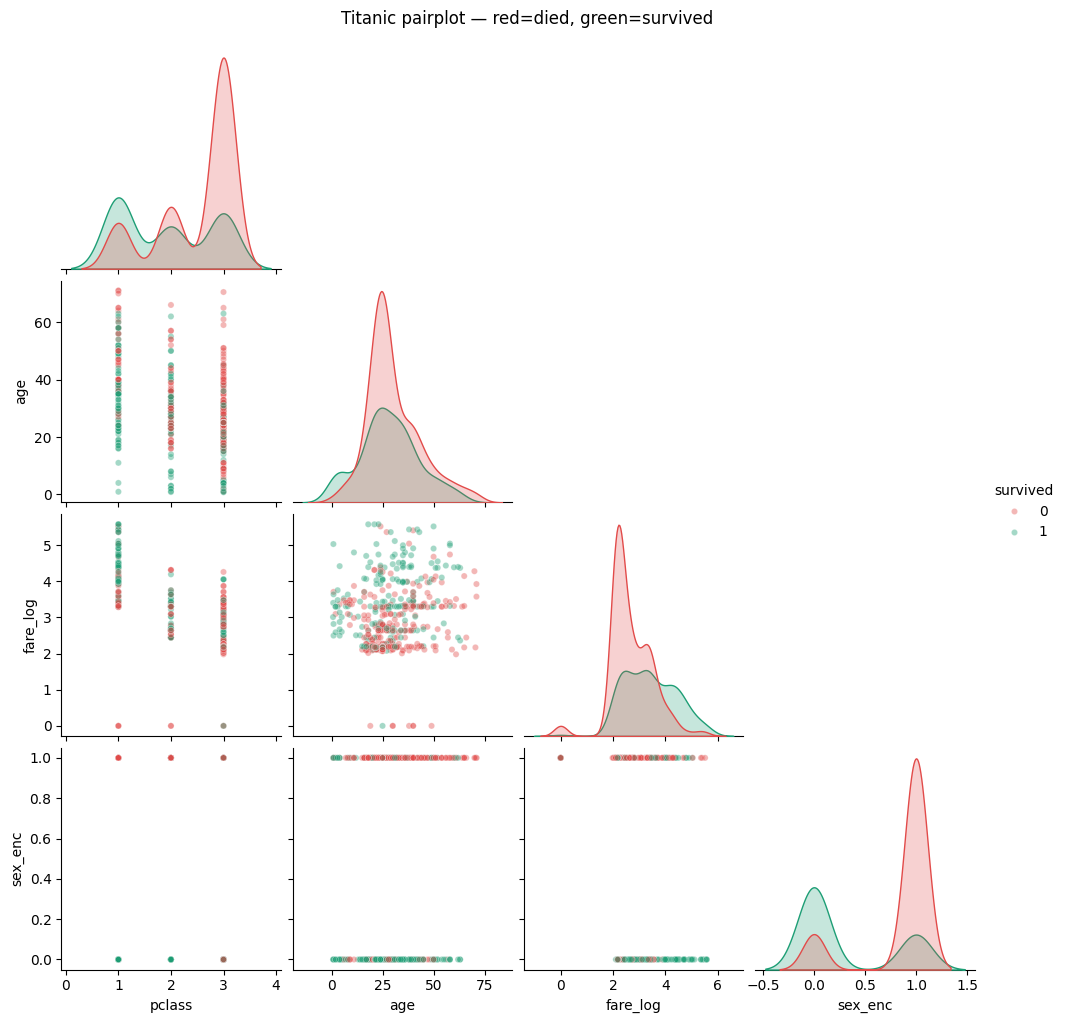

In [ ]:
cols = ['survived','pclass','age','fare_log','sex_enc']
sample = df[cols].sample(500, random_state=42)

g = sns.pairplot(sample,
                 hue='survived',
                 palette={0:'#E24B4A', 1:'#1D9E75'},
                 plot_kws={'alpha':0.4, 's':20},
                 diag_kind='kde',
                 corner=True)

plt.suptitle('Titanic pairplot — red=died, green=survived', y=1.02)
plt.show()

In [ ]:
# Finding: "family size matters" → make it a column
df['family_size'] = df['sibsp'] + df['parch']

# Finding: "travelling alone is worse" → flag it
df['is_alone'] = (df['family_size'] == 0).astype(int)

# Finding: "title carries age + class info" → extract it
if 'name' in df.columns:
    df['title'] = df['name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['title'] = df['title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr',
         'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['title'] = df['title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

    print(df.groupby('title')['survived'].mean().round(2).sort_values())
    # Mr      0.16
    # Master  0.58
    # Miss    0.70
    # Mrs     0.79
else:
    print("Error: The 'name' column is missing from the DataFrame. Please ensure it is present after previous data loading and preprocessing steps.")

Error: The 'name' column is missing from the DataFrame. Please ensure it is present after previous data loading and preprocessing steps.


(891, 15) 
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
age: skew=0.53
fare: skew=4.79
sibsp: skew=3.70
parch: skew=2.75
pclass  sex   
1       female    0.97
        male      0.37
2       female    0.92
        male      0.16
3       female    0.50
        male      0.14
Name: survived, dtype: float64


/tmp/ipykernel_1420/2300164532.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['embarked'].fillna('S', inplace=True)
/tmp/ipykernel_1420/2300164532.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

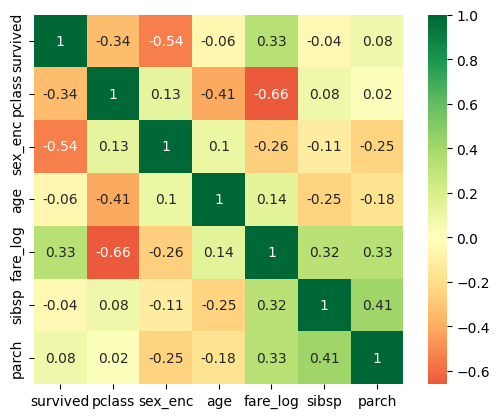

fare_log       0.285
age            0.271
sex_enc        0.256
pclass         0.072
family_size    0.063
has_cabin      0.040
is_alone       0.013
dtype: float64

EDA complete. Dataset ready for modelling.


In [ ]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

df = sns.load_dataset('titanic')

# Phase 1 — inspect
print(df.shape, '\n', df.isnull().sum())

# Phase 2 — missing data
df['has_cabin'] = df['deck'].notnull().astype(int)
df.drop(columns=['deck'], inplace=True)
df['age'] = df.groupby(['pclass','sex'])['age'].transform(lambda x: x.fillna(x.median()))
df['embarked'].fillna('S', inplace=True)
df['embark_town'].fillna('Southampton', inplace=True) # Fill missing embark_town values
assert df.isnull().sum().sum() == 0

# Phase 3 — univariate
for col in ['age','fare','sibsp','parch']:
    print(f"{col}: skew={df[col].skew():.2f}")

# Phase 4 — bivariate
print(df.groupby(['pclass','sex'])['survived'].mean().round(2))

# Phase 5 — outlier treatment
df['fare_log']    = np.log1p(df['fare'])
df['sex_enc']     = (df['sex']=='male').astype(int)
df['family_size'] = df['sibsp'] + df['parch']
df['is_alone']    = (df['family_size']==0).astype(int)

# Phase 6 — multivariate
cols = ['survived','pclass','sex_enc','age','fare_log','sibsp','parch']
sns.heatmap(df[cols].corr().round(2), annot=True,
            cmap='RdYlGn', center=0, square=True)
plt.show()

features = ['pclass','sex_enc','age','fare_log',
            'family_size','has_cabin','is_alone']
m = RandomForestClassifier(n_estimators=200, random_state=42)
m.fit(df[features], df['survived'])
imp = pd.Series(m.feature_importances_,
                index=features).sort_values(ascending=False)
print(imp.round(3))
print('\nEDA complete. Dataset ready for modelling.')